In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import matplotlib.patches as mpatches
# working dir
work_path = "C:/Users/wenlou/Documents/Python Scripts"
data_path = "P:/3026008.01/Data/"
os.chdir(work_path)
from help_function import *
import json


#read subject list 
sub_id_lst = read_sub_lst()

model_config = pd.read_excel('M:/MATLAB/Model/m_config.xlsx')
metrics = 'BIC'
m_score = pd.read_csv('M:/MATLAB/Model/check_performance/AIC_BIC_update.csv')

In [20]:
m_map ={'BayMS_Bay_Bay':70, 'BayMS_xdiff_xdiff':74}

In [21]:
m_score

,m_id,sub_id,AIC,BIC
0,87,1,7303.704485,7358.615361
1,87,2,6926.303585,6981.214461
2,87,3,3692.588463,3747.499339
3,87,4,7846.239874,7901.150750
4,87,5,6573.734282,6628.645158
...,...,...,...,...
403,74,39,5741.136679,5796.047555
404,74,41,6573.444692,6628.355568
405,74,43,6338.197066,6393.107942
406,74,44,6016.175068,6071.085944


In [22]:
df=m_score.loc[m_score.m_id.isin(m_map.values())].copy()
df.loc[:, 'm_name'] = df.loc[:, 'm_id'].map({v: k for k, v in m_map.items()})
df


,m_id,sub_id,AIC,BIC,m_name
272,70,1,6799.437976,6854.348852,BayMS_Bay_Bay
273,70,2,6399.177771,6454.088647,BayMS_Bay_Bay
274,70,3,3761.599976,3816.510852,BayMS_Bay_Bay
275,70,4,7621.072364,7675.983240,BayMS_Bay_Bay
276,70,5,6371.440708,6426.351584,BayMS_Bay_Bay
...,...,...,...,...,...
403,74,39,5741.136679,5796.047555,BayMS_xdiff_xdiff
404,74,41,6573.444692,6628.355568,BayMS_xdiff_xdiff
405,74,43,6338.197066,6393.107942,BayMS_xdiff_xdiff
406,74,44,6016.175068,6071.085944,BayMS_xdiff_xdiff


<Axes: xlabel='sub_id'>

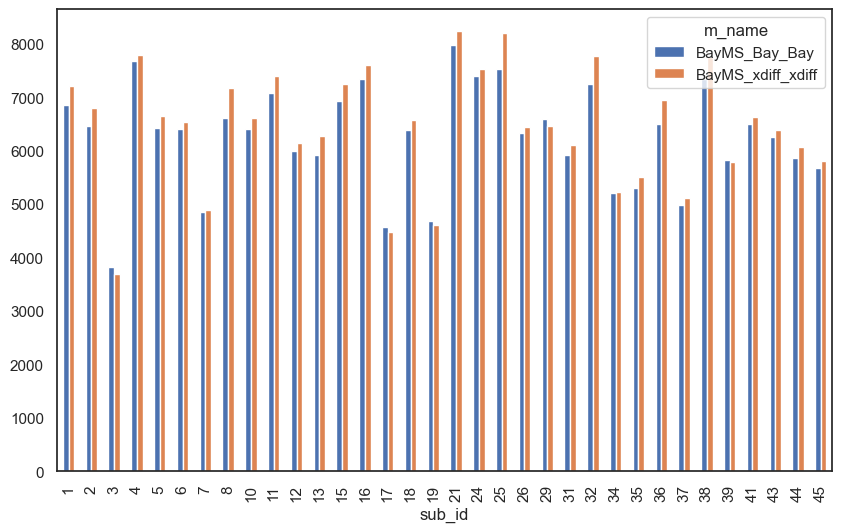

In [23]:
df.pivot(index='sub_id', columns='m_name', values=metrics).plot(kind='bar', figsize=(10, 6))

In [24]:
#pivot table
df_test = df.pivot(index='sub_id', columns='m_name', values=metrics).reset_index().copy()
df_test["delta_BIC"] = df_test["BayMS_xdiff_xdiff"] - df_test["BayMS_Bay_Bay"]
df_test 

m_name,sub_id,BayMS_Bay_Bay,BayMS_xdiff_xdiff,delta_BIC
0,1,6854.348852,7203.598276,349.249424
1,2,6454.088647,6796.984876,342.896229
2,3,3816.510852,3692.123249,-124.387603
3,4,7675.983240,7793.975476,117.992236
4,5,6426.351584,6650.651676,224.300092
5,6,6412.077831,6544.361876,132.284045
6,7,4842.524050,4883.860876,41.336826
7,8,6613.477611,7167.692542,554.214931
8,10,6398.474276,6601.514476,203.040200
9,11,7073.572423,7393.122543,319.550120


In [ ]:
df_test["delta_BIC"].describe()

count     34.000000
mean     201.030418
std      191.890395
min     -134.591228
25%      120.972226
50%      182.795281
75%      321.604961
max      683.864469
Name: delta_BIC, dtype: float64

In [43]:
from scipy.stats import permutation_test

# Arrays: one value per participant
bic_baybay = df_test["BayMS_Bay_Bay"].to_numpy()
bic_xdiff = df_test["BayMS_xdiff_xdiff"].to_numpy()

# Statistic: mean BIC difference
# Positive = lower BIC for Bay-Bay
def statistic(x, y, axis=0):
    return np.mean(y - x, axis=axis)

result = permutation_test(
    data=(bic_baybay, bic_xdiff),
    statistic=statistic,
    permutation_type="samples",
    alternative="greater",
    n_resamples=100_000,
    random_state=72
)

print("Observed mean ΔBIC:", result.statistic)
print("p-value:", result.pvalue)

Observed mean ΔBIC: 201.03041805276325
p-value: 9.99990000099999e-06


In [36]:
result

PermutationTestResult(statistic=np.float64(201.03041805276325), pvalue=np.float64(9.99990000099999e-06), null_distribution=array([ -31.28908739,   52.3167708 ,  -57.52708024, ...,   20.24978873,
        -14.61351418, -103.02754637], shape=(100000,)))

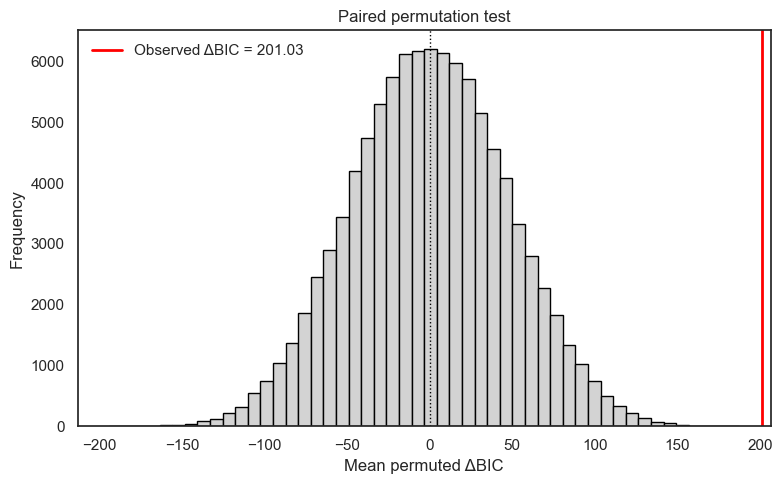

In [41]:

# ---------------------------------------------------------
# 7. Plot permutation distribution
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    result.null_distribution,
    bins=50,
    color="lightgray",
    edgecolor="black"
)

plt.axvline(
    result.statistic,
    color="red",
    linewidth=2,
    label=f"Observed ΔBIC = {result.statistic:.2f}"
)

plt.axvline(
    0,
    color="black",
    linestyle=":",
    linewidth=1
)

plt.xlabel("Mean permuted ΔBIC")
plt.ylabel("Frequency")
plt.title("Paired permutation test")
plt.legend(frameon=False, loc="upper left")

plt.tight_layout()
plt.show()


In [42]:

# ---------------------------------------------------------
# 6. Approximate Bayes factor for each participant
# ---------------------------------------------------------

# log BF(Bay-Bay vs xDiff-xDiff) ≈ ΔBIC / 2

df_test["log_BF_BayBay_vs_xDiff"] = df_test["delta_BIC"] / 2

df_test["BF_BayBay_vs_xDiff"] = np.exp(
    df_test["log_BF_BayBay_vs_xDiff"]
)

print("\nParticipant-level results:")
print(
    df_test[
        [
            "sub_id",
            "BayMS_Bay_Bay",
            "BayMS_xdiff_xdiff",
            "delta_BIC",
            "BF_BayBay_vs_xDiff"
        ]
    ]
)




Participant-level results:
m_name  sub_id  BayMS_Bay_Bay  BayMS_xdiff_xdiff   delta_BIC  \
0            1    6854.348852        7203.598276  349.249424   
1            2    6454.088647        6796.984876  342.896229   
2            3    3816.510852        3692.123249 -124.387603   
3            4    7675.983240        7793.975476  117.992236   
4            5    6426.351584        6650.651676  224.300092   
5            6    6412.077831        6544.361876  132.284045   
6            7    4842.524050        4883.860876   41.336826   
7            8    6613.477611        7167.692542  554.214931   
8           10    6398.474276        6601.514476  203.040200   
9           11    7073.572423        7393.122543  319.550120   
10          12    5986.944561        6143.110476  156.165915   
11          13    5914.024551        6272.178076  358.153525   
12          15    6924.979338        7247.269245  322.289908   
13          16    7350.148470        7609.783076  259.634606   
14          